# 2-Task Cognitive RNN Explainer

Pedagogical walkthrough of the Yang-style task battery implemented in this repo:
**fdgo** and **delaygo**.

For each task we show the **ideal inputs and targets** (before learning), then **jointly train** a Dale's-law rate RNN for 500 steps and **evaluate** the trained network.


## Shared task structure

These tasks follow the [Yang et al. (2019)](https://www.nature.com/articles/s41593-018-0310-2) multitask framework (scoped here to 3 rules, single sensory ring).

### Ring population code
Stimulus and response locations on a circle $[0, 2\pi)$ are encoded as **Gaussian bumps** over `n_eachring` units with evenly spaced preferred angles (`Trial.add_x_loc` / `add_y_loc`).

### Input channels (`x`, shape `T × n_input`)
| Index | Name | Meaning |
|-------|------|---------|
| 0 | fixation | 1 = hold fixation, 0 = go cue |
| 1 … `rule_start−1` | stimulus ring | Bump(s) at stimulus location(s) |
| `rule_start` … | rule context | One-hot over fdgo / delaygo |

### Output channels (`y`, shape `T × n_output`)
| Index | Name | Meaning |
|-------|------|---------|
| 0 | fixation | Target ~0.8 during pre-go fixation |
| 1 … | response ring | Bump at saccade target after go |

### Trial phases
Each generator stores phase boundaries in `trial.epochs` (e.g. `fix1`, `stim1`, `delay1`, `go1`) used for timeline plots.


In [2]:
from task import *

In [3]:
rule_index_map

{'all': {'fdgo': 0, 'dm1': 1, 'delaygo': 2}}

In [2]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

import torch

from task import default_config, generate_trials, rules_dict, get_dist
from model import RateRNN
from train_cog import (
    make_model,
    train,
    trial_to_tensors,
    evaluate_task,
    decode_ring,
    batch_accuracy,
    ring_prefs,
    circular_abs,
    plot_preactivation_at_init,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config = default_config(n_eachring=16, seed=0, easy_task=True)
TASKS = tuple(rules_dict["all"])

print(f"device={device}")
print(f"n_input={config['n_input']}  n_output={config['n_output']}  rule_start={config['rule_start']}")
print(f"tasks={TASKS}")


device=cpu
n_input=20  n_output=17  rule_start=17
tasks=('fdgo', 'dm1', 'delaygo')


In [3]:
def ms(t_step, dt):
    """Convert step index to milliseconds."""
    return np.asarray(t_step, dtype=float) * dt


def decode_ring_np(ring, prefs):
    """Population-vector decode (numpy). ring: (T, n_ring)."""
    ring = np.atleast_2d(ring)
    cos_c = (ring * np.cos(prefs)).sum(axis=-1)
    sin_c = (ring * np.sin(prefs)).sum(axis=-1)
    return np.arctan2(sin_c, cos_c)


def ring_bump(loc, prefs):
    dist = get_dist(loc - prefs)
    dist /= np.pi / 8
    return 0.8 * np.exp(-(dist ** 2) / 2)


def plot_ring_bump(loc, prefs, ax, color="C0", label=None):
    ax.plot(prefs, ring_bump(loc, prefs), color=color, lw=2, label=label)
    ax.set_xlim(0, 2 * np.pi)
    ax.set_xlabel("angle (rad)")
    ax.set_ylabel("amplitude")


def plot_task_timeline(trial, i=0, ax=None):
    """Horizontal bar diagram of trial.epochs."""
    dt = trial.dt
    tdim = trial.tdim
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 1.3))
    colors = {"fix1": "#999999", "stim1": "C0", "delay1": "C1", "go1": "C3"}
    for name, (start, end) in trial.epochs.items():
        s = 0 if start is None else start
        e = tdim if end is None else end
        ax.barh(0.5, (e - s) * dt, left=s * dt, height=0.55, color=colors.get(name, "gray"), label=name, edgecolor="white")
    ax.set_xlim(0, tdim * dt)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("time (ms)")
    ax.set_title("Trial phases")
    ax.legend(loc="upper right", ncol=4, fontsize=8)
    return ax


def _go_onset_step(trial):
    go = trial.epochs.get("go1", (None, None))
    return go[0]


def plot_trial_ideal(trial, config, i=0, title=None):
    """3-row explainer: scalar inputs, input ring imshow, target output imshow."""
    dt = config["dt"]
    rule_start = config["rule_start"]
    prefs = trial.pref
    T = trial.tdim
    t_ms = ms(np.arange(T), dt)
    x = trial.x[:, i]
    y = trial.y[:, i]
    go_step = _go_onset_step(trial)
    go_ms = go_step * dt if go_step is not None else None

    fig = plt.figure(figsize=(11, 7.5), layout="constrained")
    gs = GridSpec(3, 1, height_ratios=[1, 1.35, 1.35])
    ax0 = fig.add_subplot(gs[0])
    ax1 = fig.add_subplot(gs[1])
    ax2 = fig.add_subplot(gs[2])

    fix_in = x[:, 0]
    go_cue = 1.0 - fix_in
    context = x[:, rule_start:].max(axis=1)
    ax0.plot(t_ms, fix_in, "k-", lw=1.5, label="fixation in")
    ax0.plot(t_ms, go_cue, color="C3", lw=1.5, label="go cue (1-fix)")
    ax0.plot(t_ms, context, color="C1", lw=1.2, label="rule context")
    ax0.set_ylabel("scalar inputs")
    ax0.set_ylim(-0.05, 1.15)
    ax0.legend(loc="upper right", fontsize=8)
    ax0.grid(True, alpha=0.3)
    if go_ms is not None:
        for ax in (ax0, ax1, ax2):
            ax.axvline(go_ms, color="gray", ls="--", alpha=0.75, lw=1)

    stim_ring = x[:, 1:rule_start].T
    im1 = ax1.imshow(stim_ring, aspect="auto", origin="lower", cmap="Blues",
                      extent=[0, t_ms[-1] + dt, 0, len(prefs) - 1], vmin=0)
    ax1.set_ylabel("ring unit")
    ax1.set_title("Input stimulus ring")
    in_ang = decode_ring_np(x[:, 1:rule_start], prefs)
    ax1b = ax1.twinx()
    ax1b.plot(t_ms, np.degrees(in_ang), "r-", lw=0.9, alpha=0.75)
    ax1b.set_ylabel("decoded input (deg)", color="r")
    ax1b.set_yticks([])
    fig.colorbar(im1, ax=ax1, fraction=0.025, pad=0.02, label="input amp")

    fix_tgt = y[:, 0]
    out_ring = y[:, 1:].T
    ax2.plot(t_ms, fix_tgt, "k--", lw=1.2, label="fixation target")
    im2 = ax2.imshow(out_ring, aspect="auto", origin="lower", cmap="Oranges",
                      extent=[0, t_ms[-1] + dt, 0, len(prefs) - 1], vmin=0)
    ax2.set_ylabel("ring unit")
    ax2.set_xlabel("time (ms)")
    ax2.set_title("Target output (fixation + response ring)")
    ax2.legend(loc="upper left", fontsize=8)
    fig.colorbar(im2, ax=ax2, fraction=0.025, pad=0.02, label="target amp")

    if title:
        fig.suptitle(title, fontsize=13)
    plt.show()
    return fig


def plot_dm1_stim_snapshot(trial, config, i=0):
    """1D plot of the two simultaneous input bumps during stim1."""
    rule_start = config["rule_start"]
    prefs = trial.pref
    stim_on = trial.epochs["stim1"][0]
    ring = trial.x[stim_on, i, 1:rule_start]
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(prefs, ring, "C0", lw=2)
    ax.set_title(f"dm1 input ring at stim onset (t={stim_on * config['dt']:.0f} ms)")
    ax.set_xlabel("angle (rad)")
    ax.set_ylabel("amplitude")
    ax.grid(True, alpha=0.3)
    plt.show()
    return fig


def demo_trial(task, title=None):
    trial = generate_trials(task, config, batch_size=1, noise_on=False)
    plot_task_timeline(trial)
    plt.show()
    plot_trial_ideal(trial, config, i=0, title=title or task)
    return trial


## Task 1: `fdgo` — fixation-duration go

**Cognitive demand:** Stimulus stays on until the go cue. After fixation offset, saccade to the **visible** stimulus location.

**Why it is the easiest:** Minimal working memory — the ring input is present throughout the pre-go period, so the network can rely largely on feedforward mapping from stimulus to response.

**Ideal behavior:**
- Pre-go: hold fixation (output ch 0 high), response ring flat
- Post-go: fixation target drops, response ring bump at stimulus angle

**Epochs:** `fix1` → `stim1` (overlapping) → `go1`


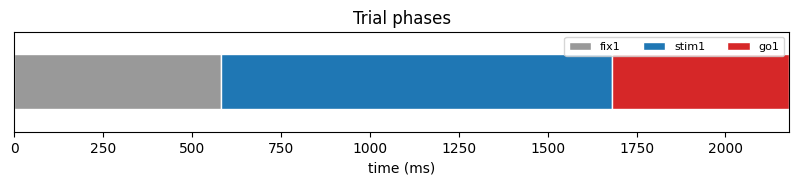

c:\Users\athar\miniconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


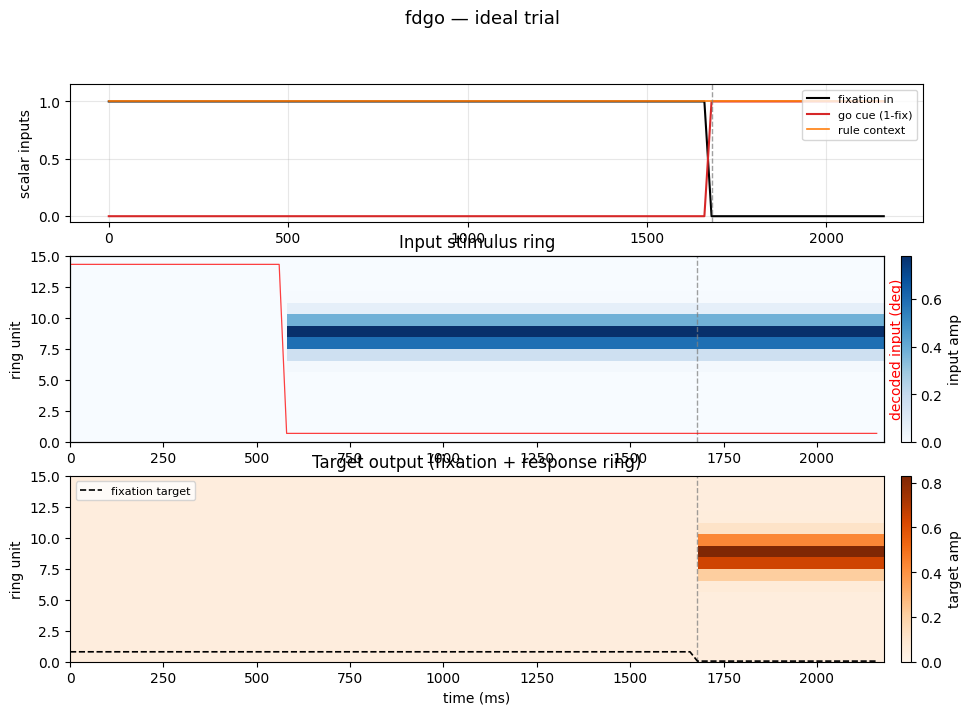

In [4]:
trial_fdgo = demo_trial("fdgo", title="fdgo — ideal trial")


## Task 2: `dm1` — perceptual decision (two stimuli)

**Cognitive demand:** Two stimuli appear **simultaneously** on the same ring with different strengths (coherence). Integrate evidence and, at go, respond at the **stronger** stimulus location.

**Ideal behavior:**
- Input ring shows **two bumps** during `stim1`
- Target ring shows a **single** bump at the winner location after go

**Epochs:** `fix1` → `stim1` → `go1`


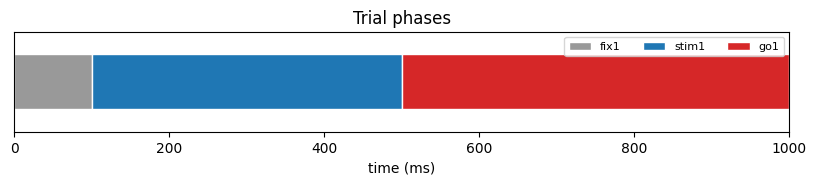

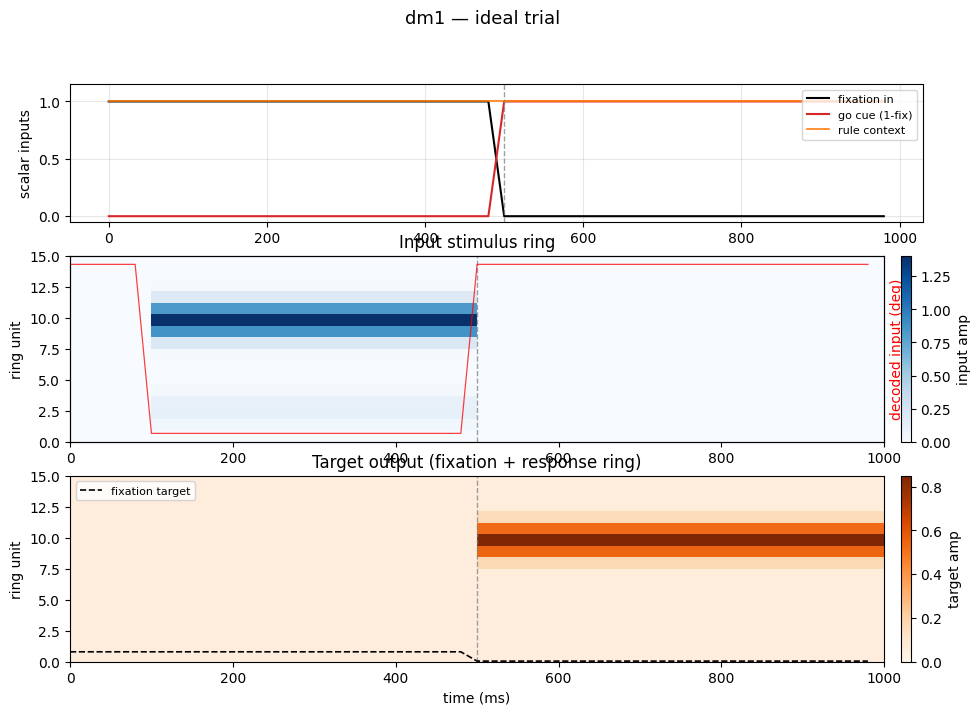

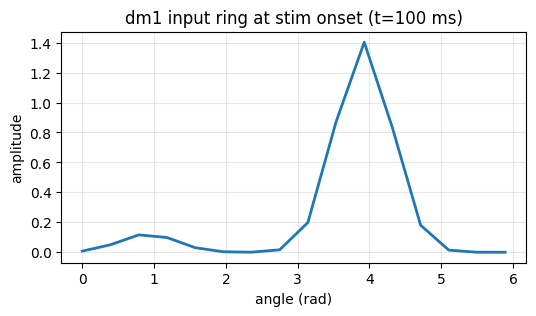

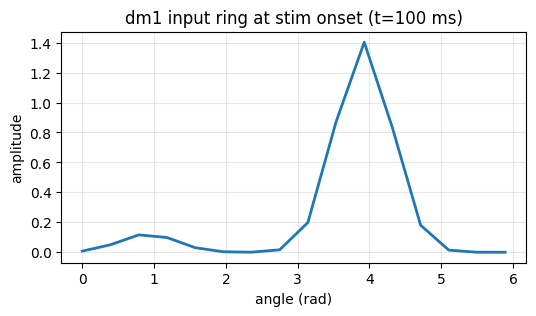

In [5]:
# dm1 demo removed — not in rules_dict["all"]


## Task 2: `delaygo` — working-memory go

**Cognitive demand:** Stimulus is shown briefly, then **removed** during a delay. At go, respond at the **remembered** location (no stimulus on the input ring during delay).

**Ideal behavior:**
- Input ring active only during `stim1`
- During `delay1`: no stimulus on input, but network must maintain location internally
- After go: response ring bump at memorized angle

**Epochs:** `fix1` → `stim1` → `delay1` → `go1`


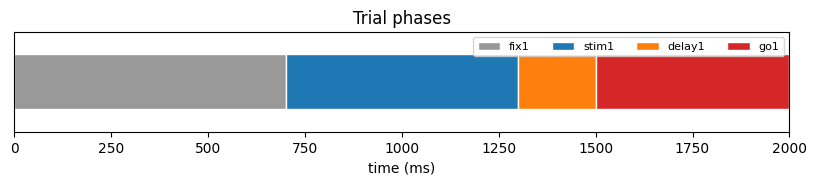

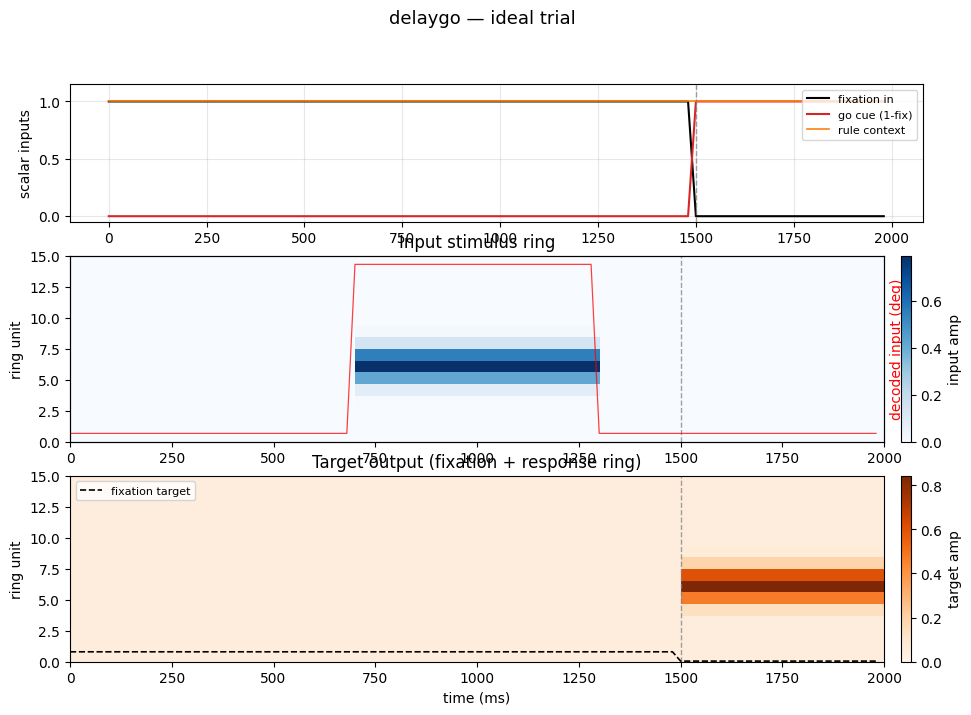

In [6]:
trial_delaygo = demo_trial("delaygo", title="delaygo — ideal trial")


## Rate RNN model

We train a **Dale's-law-constrained rate RNN** (`model.py`), aligned with [Yang et al. (2019)](https://www.nature.com/articles/s41593-018-0310-2):
- Leaky Euler dynamics: $\dot{x} = (-x + W_{rec} r + W_{in} x_{input} + b)/\tau$
- **ReLU-squared** firing rates: $r = \min(\mathrm{ReLU}(x)^2, r_{max})$ — supports integration and delay memory
- **Linear readout** from E units only (lsq ring targets; no tanh saturation)
- Dale's law: excitatory rows ≥ 0, inhibitory ≤ 0
- Init: $\rho(W_{rec}) \approx g = 1.5$ (near-critical for working memory)
- Recurrent bias $b$ init at **2.0** to bootstrap activity above the ReLU threshold


recurrent init: g=0.40  rho(W)=0.400
Model on cpu, N=32, rho(W)=0.400


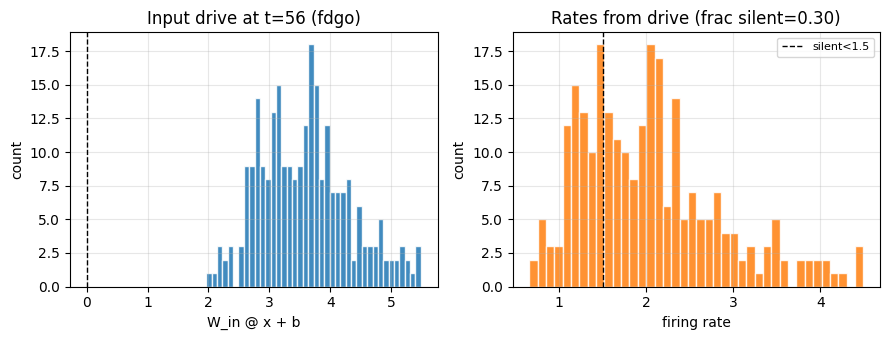

pre-act: frac negative drive=0.00, frac silent from drive alone=0.30


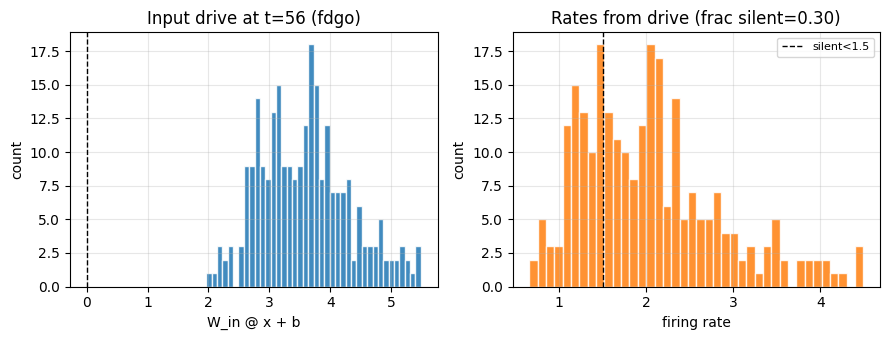

In [7]:
G = 1.5
N_RNN = 256
model = make_model(config, model_type="yang", n_rnn=N_RNN, seed=0, device=str(device))
print(f"Model on {device}, n_rnn={N_RNN}")

# Pre-activation diagnostic (Dale model only; skipped for Yang)
plot_preactivation_at_init(model, config, device=str(device), task="fdgo")


## Joint training (2000 steps)

**Mixed batches:** each step draws ~equal trials from fdgo / delaygo (padded to common length).

**Why delaygo needs more steps than fdgo:** delaygo requires maintaining a bump in hidden activity after the stimulus is removed. Both tasks use the Yang LeakyRNN with sigmoid readout and mask-weighted MSE loss.

Loss: mask-weighted MSE (`c_mask`, normalized). Rate regularization off.

**Note:** 2000 steps on CPU may take 10–20 minutes. Watch the silent-fraction panel — should stay well below 1.0.


step    1 | train 0.8789 (mixed) | fdgo accuracy:0.000 go:0.12 fix:0.00 loss:1.0594 | dm1 accuracy:0.000 go:0.14 fix:0.00 loss:1.2048 | delaygo accuracy:0.000 go:0.16 fix:0.00 loss:0.5740 | sat:0.00; silent:0.24
step   20 | train 0.3970 (mixed) | fdgo accuracy:0.000 go:0.27 fix:0.00 loss:0.4488 | dm1 accuracy:0.000 go:0.22 fix:0.00 loss:0.4509 | delaygo accuracy:0.000 go:0.22 fix:0.00 loss:0.2808 | sat:0.00; silent:0.27
step   40 | train 0.1485 (mixed) | fdgo accuracy:0.000 go:0.12 fix:0.00 loss:0.1555 | dm1 accuracy:0.000 go:0.14 fix:0.25 loss:0.1865 | delaygo accuracy:0.000 go:0.20 fix:0.00 loss:0.1353 | sat:0.00; silent:0.37
step   60 | train 0.1046 (mixed) | fdgo accuracy:0.000 go:0.17 fix:0.00 loss:0.1456 | dm1 accuracy:0.266 go:0.31 fix:0.84 loss:0.1608 | delaygo accuracy:0.000 go:0.23 fix:0.00 loss:0.0796 | sat:0.00; silent:0.27
step   80 | train 0.1032 (mixed) | fdgo accuracy:0.000 go:0.12 fix:0.00 loss:0.1203 | dm1 accuracy:0.016 go:0.16 fix:0.31 loss:0.1473 | delaygo accuracy

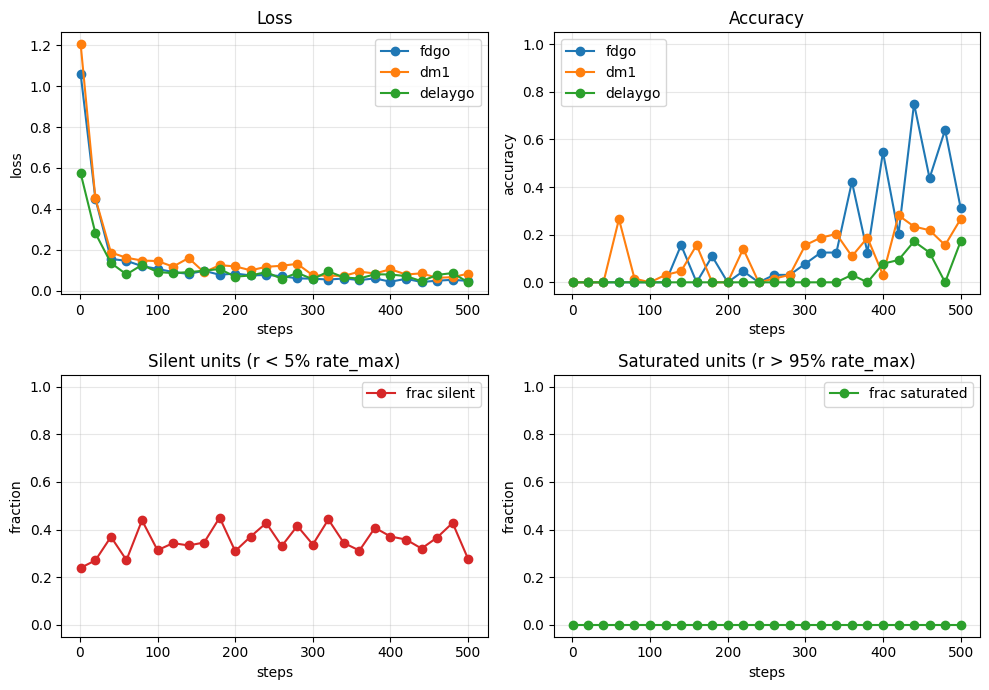

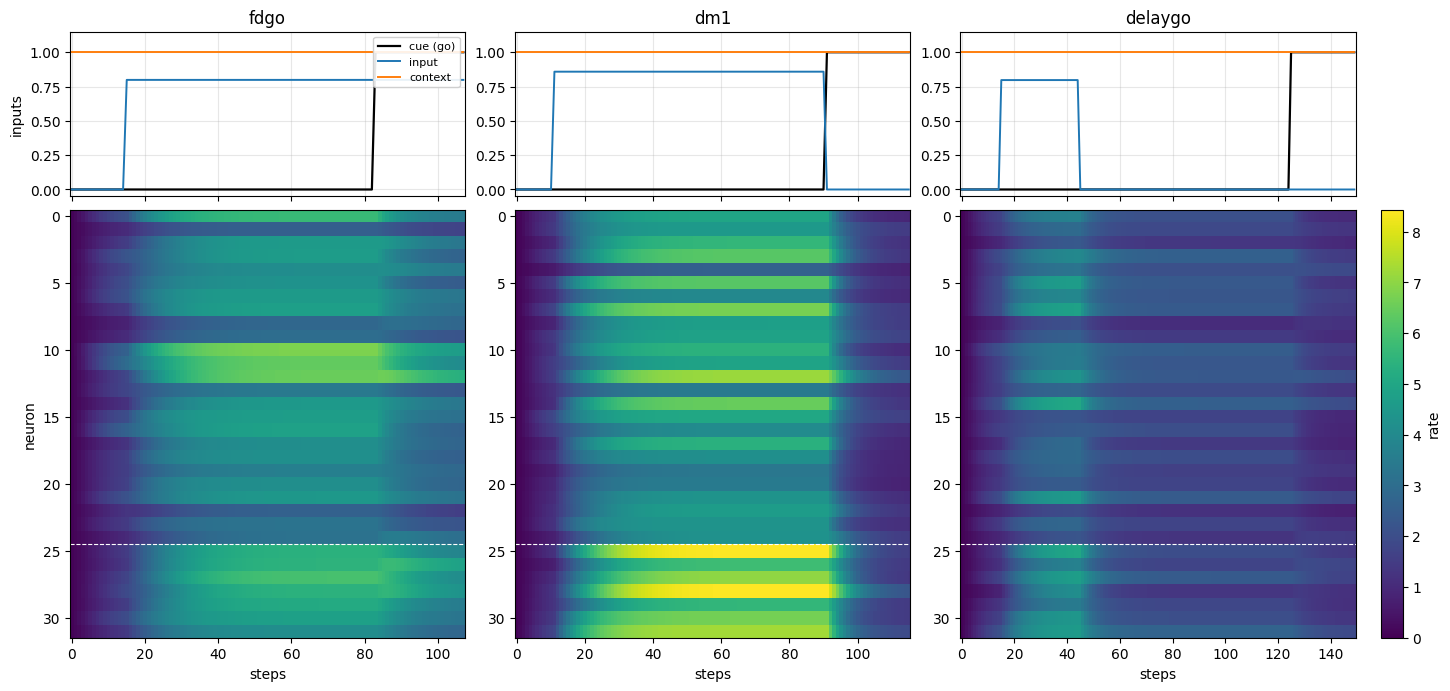

In [8]:
history = train(
    model,
    config,
    active_tasks=TASKS,
    n_steps=2000,
    batch_size=64,
    lr=1e-3,
    log_every=100,
    lambda_rate=0.0,
)


## Post-training evaluation

Evaluate the trained network on held-out batches and compare predictions to targets.

**Accuracy definition** (`batch_accuracy` in `train_cog.py`): a trial is correct if (1) during fixation, mean predicted fixation channel $> 0.5$, and (2) after go, population-vector decode error $< \pi/5$ rad ($\approx 36°$) from target location.


In [9]:
# Per-task accuracy table
for task in TASKS:
    m = evaluate_task(model, config, task, batch_size=64, device=str(device))
    print(
        f"{task:8s}  acc={m['acc']:.3f}  go={m['go_acc']:.2f}  fix={m['fix_acc']:.2f}  "
        f"loss={m['loss']:.4f}  silent={m['activity']['frac_silent']:.2f}"
    )


fdgo      acc=0.844  go=0.94  fix=0.91  loss=0.0416  silent=0.15
dm1       acc=0.141  go=0.17  fix=0.55  loss=0.1001  silent=0.36
delaygo   acc=0.203  go=0.20  fix=1.00  loss=0.0443  silent=0.32


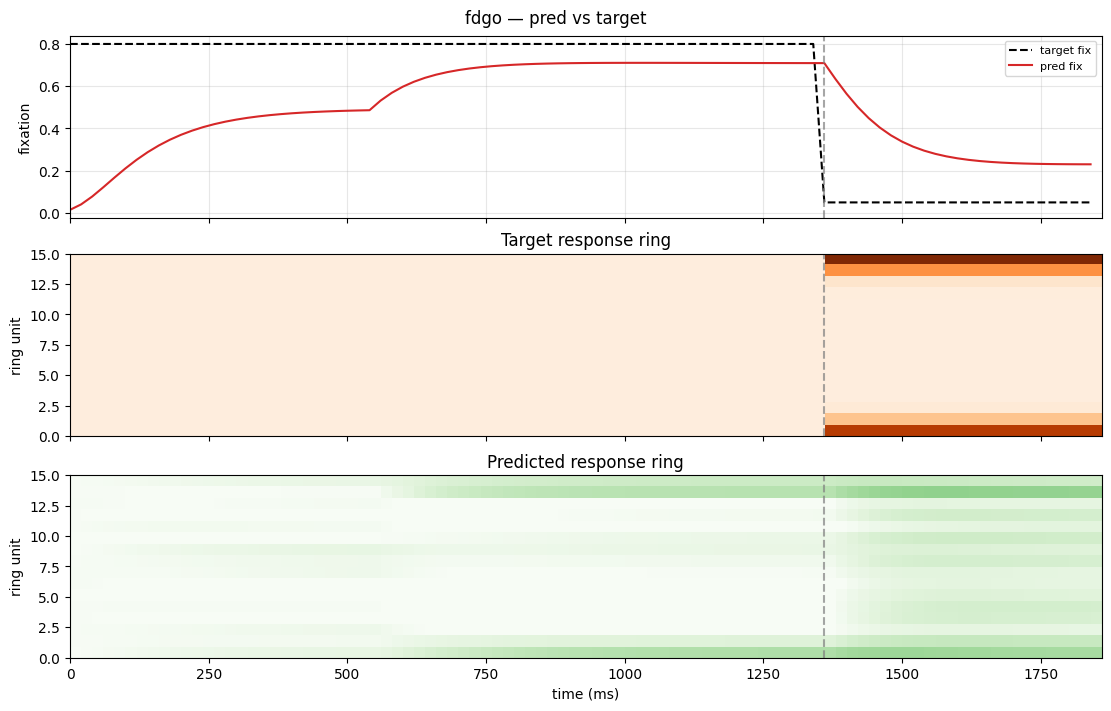

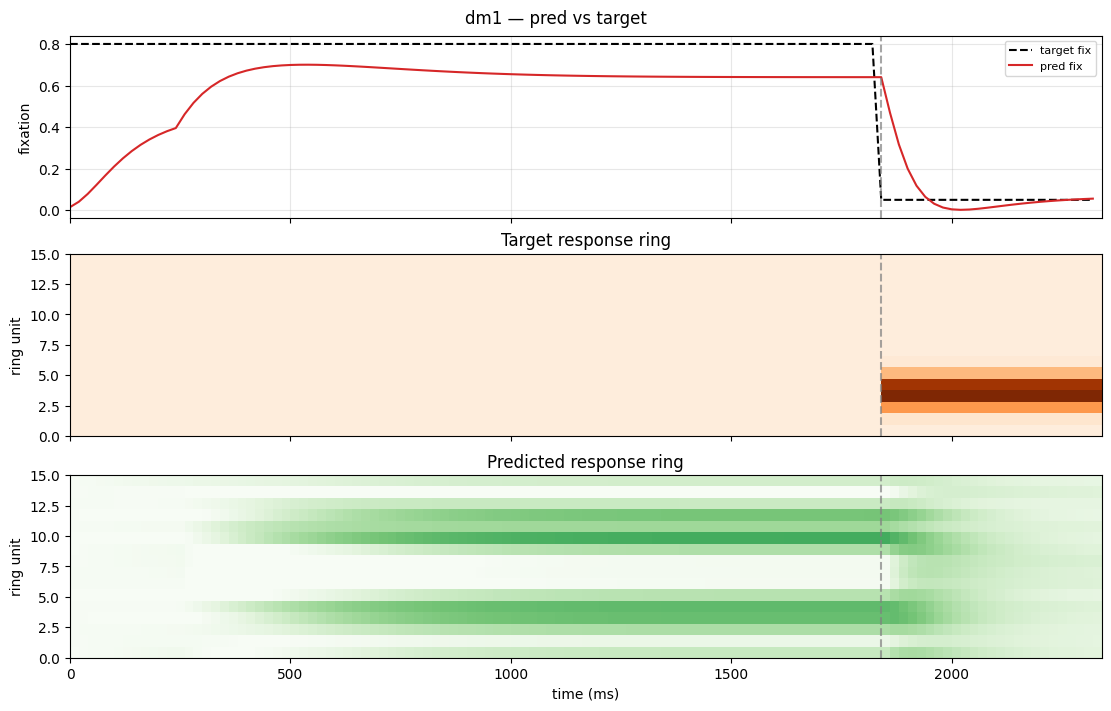

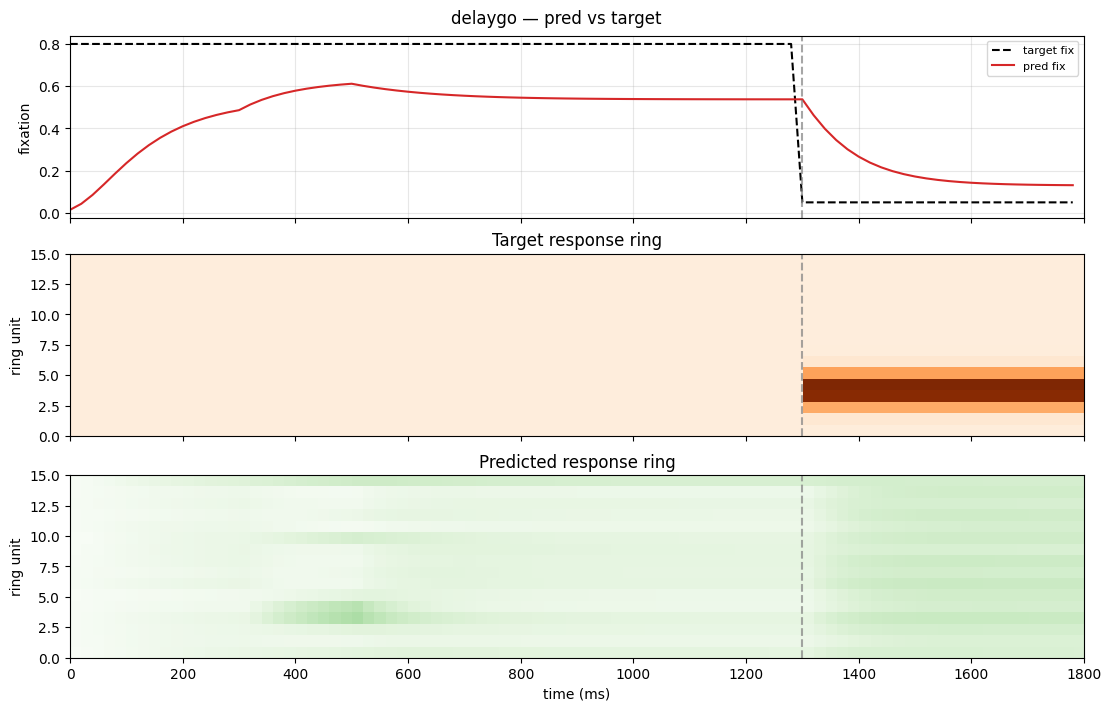

In [10]:
def plot_pred_vs_target(model, config, task, device):
    # Compare model output to target for one noiseless trial.
    trial = generate_trials(task, config, batch_size=1, noise_on=False)
    x, y, _, y_loc = trial_to_tensors(trial, device)
    with torch.no_grad():
        _, _, output = model.simulate(x, noise_level=0.0)
    dt = config["dt"]
    T = trial.tdim
    t_ms = ms(np.arange(T), dt)
    out_np = output[0].cpu().numpy()
    y_np = y[0].cpu().numpy()
    go_ms = _go_onset_step(trial) * dt

    fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True, layout="constrained")
    axes[0].plot(t_ms, y_np[:, 0], "k--", label="target fix")
    axes[0].plot(t_ms, out_np[:, 0], "C3", label="pred fix")
    axes[0].set_ylabel("fixation")
    axes[0].legend(fontsize=8)
    axes[0].grid(True, alpha=0.3)

    vmax = max(y_np[:, 1:].max(), out_np[:, 1:].max(), 0.1)
    axes[1].imshow(y_np[:, 1:].T, aspect="auto", origin="lower", cmap="Oranges",
                   extent=[0, t_ms[-1] + dt, 0, config["n_eachring"] - 1], vmin=0, vmax=vmax)
    axes[1].set_ylabel("ring unit")
    axes[1].set_title("Target response ring")
    axes[2].imshow(out_np[:, 1:].T, aspect="auto", origin="lower", cmap="Greens",
                   extent=[0, t_ms[-1] + dt, 0, config["n_eachring"] - 1], vmin=0, vmax=vmax)
    axes[2].set_ylabel("ring unit")
    axes[2].set_xlabel("time (ms)")
    axes[2].set_title("Predicted response ring")
    for ax in axes:
        ax.axvline(go_ms, color="gray", ls="--", alpha=0.7)
    fig.suptitle(f"{task} — pred vs target")
    plt.show()
    return fig


for task in TASKS:
    plot_pred_vs_target(model, config, task, str(device))


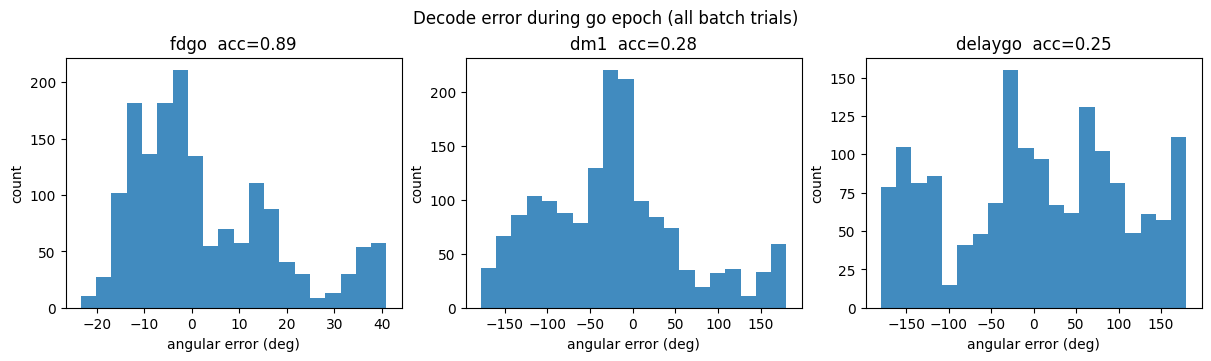

In [11]:
# Circular decode error distribution (go period only)
prefs = ring_prefs(config, device, torch.float32)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), layout="constrained")
for ax, task in zip(axes, TASKS):
    trial = generate_trials(task, config, batch_size=64, noise_on=True)
    x, y, _, y_loc = trial_to_tensors(trial, device)
    with torch.no_grad():
        _, _, output = model.simulate(x, noise_level=0.0)
    pred_loc = decode_ring(output, prefs)
    go = y_loc >= 0
    err = circular_abs((pred_loc - y_loc).masked_fill(~go, 0.0))
    err_deg = err[go].detach().cpu().numpy().ravel() * 180 / math.pi
    ax.hist(err_deg, bins=20, color="C0", alpha=0.85)
    acc = batch_accuracy(output, y_loc, prefs)
    ax.set_title(f"{task}  acc={acc['acc']:.2f}")
    ax.set_xlabel("angular error (deg)")
    ax.set_ylabel("count")
fig.suptitle("Decode error during go epoch (all batch trials)")
plt.show()


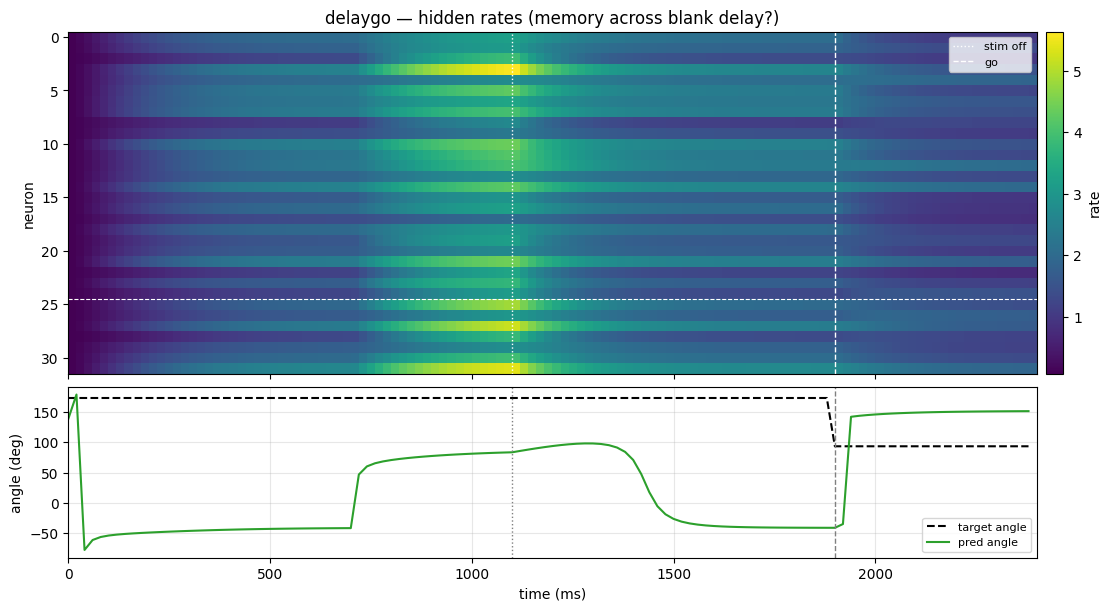

In [12]:
# delaygo memory check: hidden rates + decoded output angle through delay
task = "delaygo"
trial = generate_trials(task, config, batch_size=1, noise_on=False)
x, y, _, y_loc = trial_to_tensors(trial, device)
with torch.no_grad():
    r_hist, _, output = model.simulate(x, noise_level=0.0)

dt = config["dt"]
T = trial.tdim
t_ms = ms(np.arange(T), dt)
r_np = r_hist[0].cpu().numpy().T
out_np = output[0].cpu().numpy()
prefs_t = ring_prefs(config, device, output.dtype)
pred_ang = decode_ring(output, prefs_t)[0].cpu().numpy()
tgt_ang = decode_ring_np(y[0].cpu().numpy()[:, 1:], trial.pref)

stim_off = trial.epochs["stim1"][1] * dt
go_ms = _go_onset_step(trial) * dt

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, layout="constrained", height_ratios=[2, 1])
im = axes[0].imshow(r_np, aspect="auto", origin="upper", cmap="viridis",
                     extent=[0, t_ms[-1] + dt, r_np.shape[0] - 0.5, -0.5])
axes[0].axhline(model.n_e - 0.5, color="w", ls="--", lw=0.8)
axes[0].axvline(stim_off, color="w", ls=":", lw=1, label="stim off")
axes[0].axvline(go_ms, color="w", ls="--", lw=1, label="go")
axes[0].set_ylabel("neuron")
axes[0].set_title("delaygo — hidden rates (memory across blank delay?)")
axes[0].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[0], fraction=0.02, pad=0.01, label="rate")

axes[1].plot(t_ms, np.degrees(tgt_ang), "k--", lw=1.5, label="target angle")
axes[1].plot(t_ms, np.degrees(pred_ang), "C2", lw=1.5, label="pred angle")
axes[1].axvline(stim_off, color="gray", ls=":", lw=1)
axes[1].axvline(go_ms, color="gray", ls="--", lw=1)
axes[1].set_xlabel("time (ms)")
axes[1].set_ylabel("angle (deg)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.show()
